# KERAS TUNER EN DATASET DE ECOM CHURN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/ecom_data_transformed.csv')
df.head(10)

,gender,marital_status,prefered_order_cat_Fashion,prefered_order_cat_Grocery,prefered_order_cat_Laptop & Accessory,prefered_order_cat_Mobile,prefered_order_cat_Mobile Phone,preferred_login_device_Computer,preferred_login_device_Mobile Phone,preferred_login_device_Phone,...,warehouse_to_home,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,day_since_last_order,cashback_amount
0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,6.0,3.0,3.0,2.0,9.0,1.0,11.0,1.0,5.0,160.0
1,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,8.0,3.0,4.0,3.0,7.0,1.0,15.0,0.0,0.0,121.0
2,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,30.0,2.0,4.0,3.0,6.0,1.0,14.0,0.0,3.0,120.0
3,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,15.0,2.0,4.0,5.0,8.0,0.0,23.0,0.0,3.0,134.0
4,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,12.0,3.0,3.0,5.0,3.0,0.0,11.0,1.0,3.0,130.0
5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,11.0,2.0,3.0,2.0,4.0,0.0,14.0,0.0,0.0,121.0
6,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,6.0,3.0,3.0,2.0,3.0,1.0,16.0,2.0,0.0,123.0
7,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,9.0,3.0,4.0,3.0,2.0,1.0,14.0,0.0,2.0,127.0
8,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,31.0,2.0,5.0,3.0,2.0,0.0,12.0,1.0,1.0,123.0
9,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,6.0,3.0,4.0,3.0,10.0,1.0,13.0,0.0,0.0,154.0


In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
corr_matrix = df.corr()
corr_churn = corr_matrix[['churn']].sort_values(by='churn',ascending=False)
corr_churn

,churn
churn,1.000000
complain,0.262246
marital_status,0.134560
satisfaction_score,0.131555
prefered_order_cat_Mobile Phone,0.122312
prefered_order_cat_Mobile,0.118015
number_of_device_registered,0.097851
warehouse_to_home,0.081101
preferred_payment_mode_COD,0.070926
preferred_login_device_Phone,0.068811


In [6]:
cols = corr_churn.index.tolist()
cols.remove('churn')
cols

['complain',
 'marital_status',
 'satisfaction_score',
 'prefered_order_cat_Mobile Phone',
 'prefered_order_cat_Mobile',
 'number_of_device_registered',
 'warehouse_to_home',
 'preferred_payment_mode_COD',
 'preferred_login_device_Phone',
 'city_tier',
 'preferred_payment_mode_E wallet',
 'number_of_address',
 'preferred_login_device_Computer',
 'preferred_payment_mode_CC',
 'preferred_payment_mode_Cash on Delivery',
 'gender',
 'order_amount_hike_fromlast_year',
 'hour_spend_on_app',
 'preferred_payment_mode_UPI',
 'prefered_order_cat_Fashion',
 'prefered_order_cat_Grocery',
 'coupon_used',
 'preferred_payment_mode_Debit Card',
 'preferred_payment_mode_Credit Card',
 'preferred_login_device_Mobile Phone',
 'cashback_amount',
 'prefered_order_cat_Laptop & Accessory',
 'day_since_last_order',
 'tenure']

In [7]:
X = df[cols].values
y = df['churn'].values.reshape(-1,1)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

# ENTRENAMIENTO DE RED NEURONAL

In [11]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.9 MB/s eta 0:00:00


In [12]:
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# CONSTRUIMOS UN MODELO DE HIPERPARAMETROS AJUSTABLES

In [24]:
def build_model(hp):
  model = keras.Sequential()
  model.add(keras.layers.Dense(hp.Int("units1", min_value=8, max_value=120, step=8), activation="relu", input_shape=(X_train.shape[1],)))
  model.add(keras.layers.Dense(hp.Int("units2",min_value=8,max_value=120,step=8),activation='relu'))
  model.add(keras.layers.Dense(1,activation='sigmoid'))

  model.compile(
      optimizer=keras.optimizers.Adam(hp.Choice("learning_rate",[0.001,0.01,0.1])),
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  return model

In [25]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='kt_search',
    project_name='ecom_churn'
)

Reloading Tuner from kt_search/ecom_churn/tuner0.json


In [27]:
tuner.search(X_train,y_train,epochs=20,validation_data=(X_test,y_test))

Trial 26 Complete [00h 00m 11s]
val_accuracy: 0.8502538204193115

Best val_accuracy So Far: 0.960659921169281
Total elapsed time: 00h 04m 12s


# MOSTRAMOS LOS MEJORES HIPERPARAMETROS

In [28]:
# Obtener el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Mejor configuración: {best_hps.values}")

Mejor configuración: {'units1': 64, 'units2': 120, 'learning_rate': 0.01, 'tuner/epochs': 20, 'tuner/initial_epoch': 7, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0016'}


# CREAMOS UN MODELO CON LOS MEJORES HIPERPARAMETROS

In [30]:
# Entrenar el mejor modelo encontrado
best_model = tuner.hypermodel.build(best_hps)
best_model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8445 - loss: 0.4034 - val_accuracy: 0.8528 - val_loss: 0.3361
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8882 - loss: 0.2693 - val_accuracy: 0.8756 - val_loss: 0.3081
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9084 - loss: 0.2405 - val_accuracy: 0.8706 - val_loss: 0.3061
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9155 - loss: 0.2103 - val_accuracy: 0.9023 - val_loss: 0.2757
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9263 - loss: 0.1780 - val_accuracy: 0.9086 - val_loss: 0.2517
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9427 - loss: 0.1450 - val_accuracy: 0.8909 - val_loss: 0.2741
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9459 - loss: 0.1377 - val_accuracy: 0.9112 - val_loss: 0.2561
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9643 - loss: 0.0928 - val_accuracy: 0.9086 - val_loss: 0.3025
Ep

In [31]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)
y_pred = np.round(y_pred)

score = accuracy_score(y_test,y_pred)
print(f'el accuracy es {score}')

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
el accuracy es 0.9517766497461929


<Figure size 1100x1100 with 0 Axes>

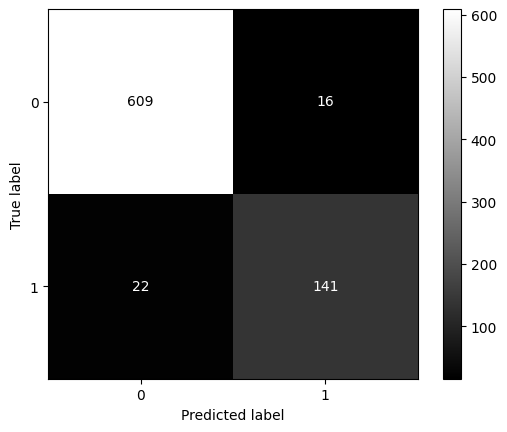

In [32]:
matrix = confusion_matrix(y_test,y_pred)
fig = plt.figure(figsize=(11,11))
cm = matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='gray')
plt.show()